In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
methods = ['cis','fci']
molecules = ['heh+','h2']
bases = ['sto-3g','6-31g','6-31gss']

In [3]:
dtstr = '0.010000'

In [4]:
cisdata = np.zeros((2,3,10))

In [5]:
for j in range(2):
    for k in range(3):
        for l in range(10):
            fname = methods[0] + '_'
            fname += molecules[j] + '_'
            fname += bases[k] + '_' + dtstr + '_'
            fname += str(l+1) + '.txt'
            cisdata[j,k,l] = np.loadtxt('./oldpinnresults/'+fname)

In [6]:
fcidata = np.zeros((2,2,100))

In [7]:
for j in range(2):
    for k in range(2):
        for l in range(100):
            fname = methods[1] + '_'
            fname += molecules[j] + '_'
            fname += bases[k] + '_' + dtstr + '_'
            if k==1:
                fname += str(5*(l+1)) + '.txt'
            else:
                fname += str(l+1) + '.txt'
                if l >= 10:
                    continue
            fcidata[j,k,l] = np.loadtxt('./oldpinnresults/'+fname)

In [8]:
newfcidata = np.zeros((2, 120))
dtstr = '0.050000'
for j in range(2):
    for l in range(120):
        fname = methods[1] + '_'
        fname += molecules[j] + '_'
        fname += bases[2] + '_' + dtstr + '_'
        fname += str(50*(l+1)) + '.txt'
        newfcidata[j,l] = np.loadtxt('./deltaresults/'+fname)    

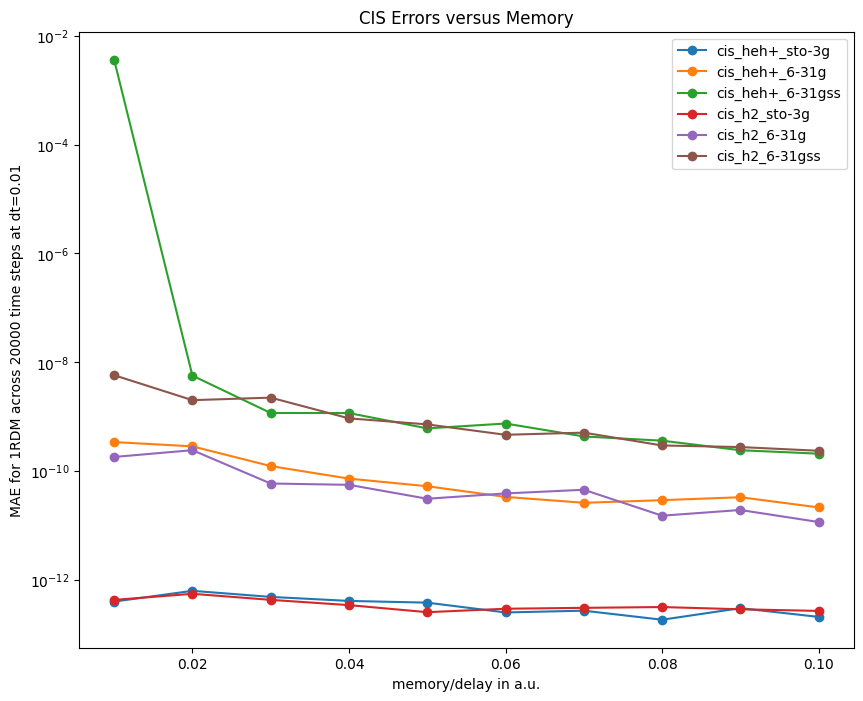

In [9]:
plt.figure(figsize=(10,8))
dt = 0.01
delayrange = np.arange(1,11)*dt
for j in range(2):
    for k in range(3):
        plt.semilogy(delayrange, cisdata[j,k,:], 'o-', label='cis_'+molecules[j]+'_'+bases[k])

plt.legend()
plt.title('CIS Errors versus Memory')
plt.ylabel('MAE for 1RDM across 20000 time steps at dt=0.01')
plt.xlabel('memory/delay in a.u.')
plt.savefig('ciserror.pdf')
plt.show()
            

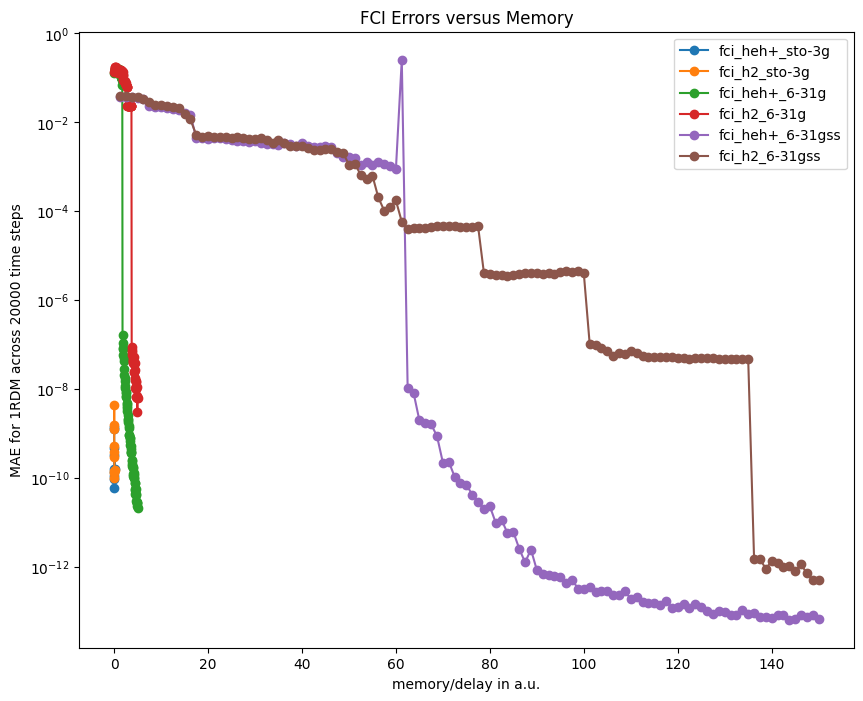

In [10]:
plt.figure(figsize=(10,8))

dt = 0.01
delayrange = np.arange(1,11)*dt
for j in range(2):
    plt.semilogy(delayrange, fcidata[j,0,:10], 'o-', label='fci_'+molecules[j]+'_'+bases[0])

delayrange = np.arange(5,505,5)*dt
for j in range(2):
    plt.semilogy(delayrange, fcidata[j,1,:], 'o-', label='fci_'+molecules[j]+'_'+bases[1])

newdt = 0.025
delayrange = np.arange(50,6050,50)*newdt
for j in range(2):
    plt.semilogy(delayrange, newfcidata[j,:], 'o-', label='fci_'+molecules[j]+'_'+bases[2])

plt.legend()
plt.title('FCI Errors versus Memory')
plt.ylabel('MAE for 1RDM across 20000 time steps')
plt.xlabel('memory/delay in a.u.')
plt.savefig('fcierror.pdf')
plt.show()
            

In [11]:
markers=['o','x']

In [15]:
def fstr(x):
    if x=='h2':
        return f"H$_2$"
    else:
        return f"HeH$^+$"

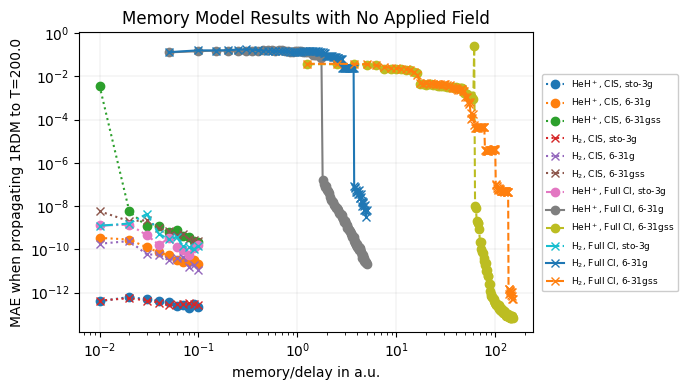

In [43]:
plt.figure(figsize=(7,4))
dt = 0.01
delayrange = np.arange(1,11)*dt
for j in range(2):
    for k in range(3):
        plt.loglog(delayrange, cisdata[j,k,:], marker=markers[j], linestyle=':', label=fstr(molecules[j])+', CIS, '+bases[k])


for j in range(2):
    dt = 0.01
    delayrange = np.arange(1,11)*dt
    plt.loglog(delayrange, fcidata[j,0,:10], marker=markers[j], linestyle='-.', label=fstr(molecules[j])+', Full CI, '+bases[0])
    delayrange = np.arange(5,505,5)*dt
    plt.loglog(delayrange, fcidata[j,1,:], marker=markers[j], linestyle='-', label=fstr(molecules[j])+', Full CI, '+bases[1])
    newdt = 0.025
    delayrange = np.arange(50,6050,50)*newdt
    plt.loglog(delayrange, newfcidata[j,:], marker=markers[j], linestyle='--',  label=fstr(molecules[j])+', Full CI, '+bases[2])


plt.title('Memory Model Results with No Applied Field')
plt.xlabel('memory/delay in a.u.')
plt.ylabel('MAE when propagating 1RDM to T=200.0')
plt.grid(True, color='grey', linewidth=0.1)
plt.legend(framealpha=1.0, facecolor='white',ncol=1, fontsize=6.5, bbox_to_anchor=(1.02, 0.86), borderaxespad=0) # loc=(0.2875,0.1), 
plt.tight_layout()
plt.savefig('FF_error.pdf')
plt.show()
            